In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
from math import radians, cos, sin, asin, sqrt
import folium
from folium import plugins
import matplotlib.ticker as ticker
from statsmodels.nonparametric.smoothers_lowess import lowess
import matplotlib.dates as mdates


### Intro
The first confirmed case of COVID-19 in the San Francisco Bay Area was recorded on January 31, 2020, marking the beginning of an unprecedented period for the city. Compared to other major US cities, San Francisco was swift and aggressive in its pandemic response. This included some of the earliest mandatory stay-at-home orders for citizens and business closures in the country. Despite having one of the highest population densities in the United States, the city recorded one of the lowest COVID-19 mortality rates nationally, which has been widely attributed to its these response efforts [ref]. While they proved effective in limiting the spread of the virus, they inevitably disrupted many aspects of daily life, particularly activities dependent on social interaction and public mobility. This is evident in when analysing the city’s crime data for the period, which reveals several interesting patterns.


### About the Dataset
The city if San Francisco makes data from its Police Department publicly available on DataSF [ref]. Two datasets, one covering the period 2003 to 2018 and the other from 2018 to present, are available on the portal. Together they span over two decades and provide a continuous records of reported crime reports. The incident data includes timestamps, incident catagories, description and spatial information. Here, a set of four crime categories will be used to explore the crime patterns in San Francisco during the COVID-19 period. These are Assault, Burglary, rug Offence and Larency-theft.

In [3]:
df = pd.read_parquet("../data/df_combined.parquet")

In [4]:
# Make 'Police District' column be all caps
df['Police District'] = df['Police District'].str.upper()

In [5]:
covid_phases = [
    {"name": "Initial Restrictions", "start": "2020-02-25", "end": "2020-06-01", "color": "#FFA500", "alpha": 0.18},
    {"name": "Partial Reopening",    "start": "2020-06-01", "end": "2020-12-06", "color": "#FFD700", "alpha": 0.18},
    {"name": "Second Lockdown",      "start": "2020-12-06", "end": "2021-01-28", "color": "#E74C3C", "alpha": 0.25},
    {"name": "Gradual Reopening",    "start": "2021-01-28", "end": "2022-06-01", "color": "#2ECC71", "alpha": 0.18},
]

category_colors = {
    'Assault':      '#1B6CA8',  # deep blue
    'Burglary':     '#7B2D8B',  # deep purple
    'Drug Offense': '#1A8C6E',  # deep teal — distinct from phase green
    'Larceny-theft':'#C0392B',  # deep crimson — distinct from phase red
}

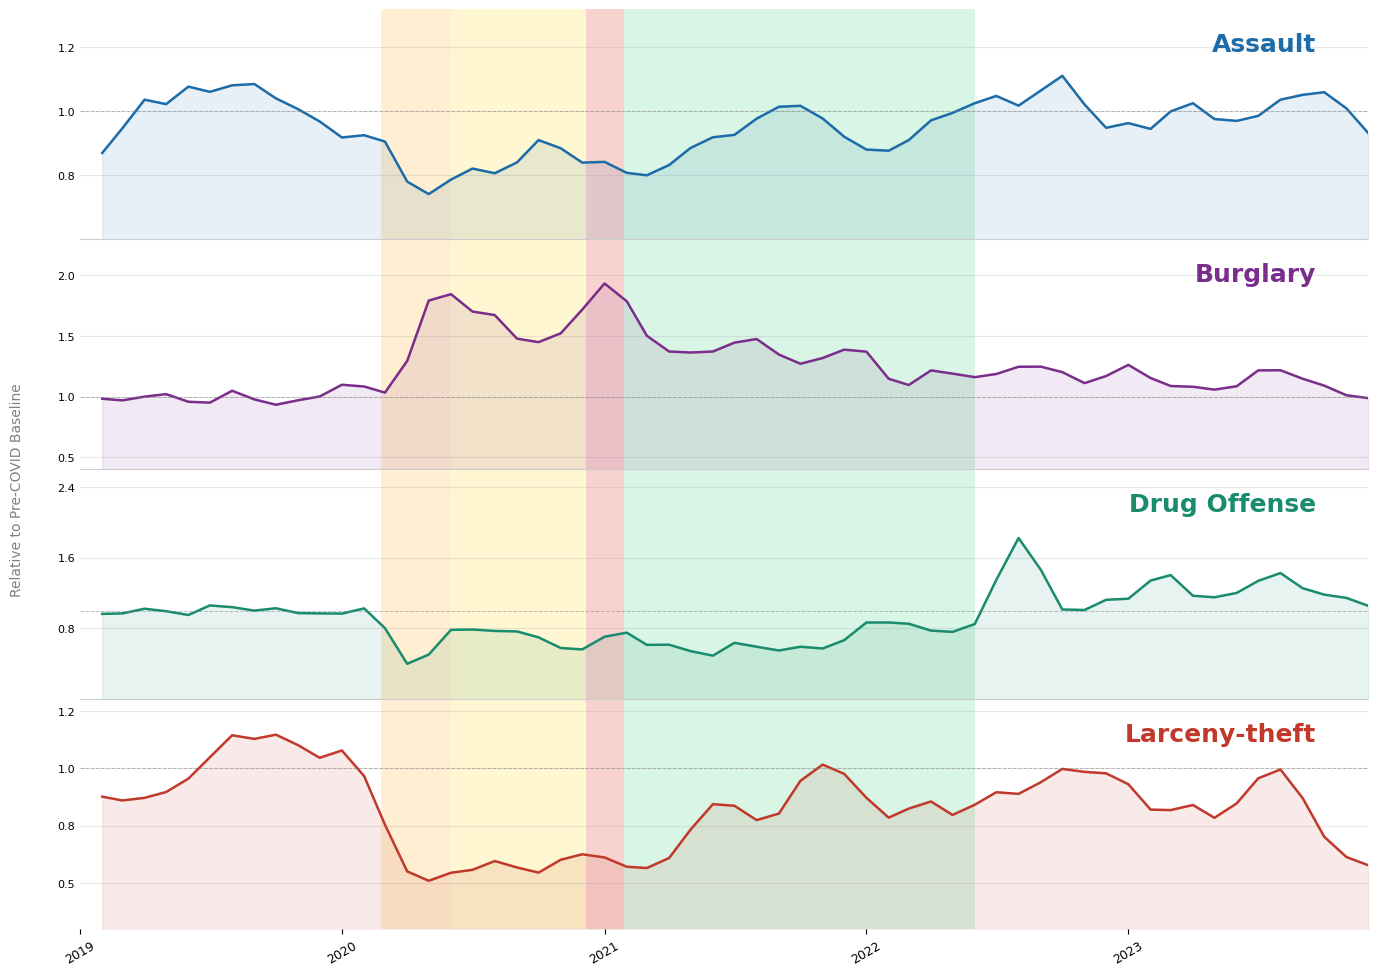

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

categories = ['Assault', 'Burglary', 'Drug Offense', 'Larceny-theft']

df_filtered = df[(df['Year'] >= 2019) & (df['Year'] <= 2023) &
                 (df['Crime Category'].isin(categories))].copy()

for phase in covid_phases:
    phase["start"] = pd.Timestamp(phase["start"])
    phase["end"]   = pd.Timestamp(phase["end"])

baseline_start = pd.Timestamp("2018-01-01")
baseline_end   = pd.Timestamp("2020-02-25")

ROLLING_WINDOW = 2

ylim_overrides = {
    'Assault':       (0.5, 1.4),
    'Burglary':      (0.4, 2.3),    
    'Drug Offense': (0.0, 2.6),
    'Larceny-theft': (0.3, 1.3),
}

fig, axes = plt.subplots(len(categories), 1, figsize=(14, 10), sharex=True)
fig.subplots_adjust(hspace=0, top=0.98, bottom=0.06, left=0.06, right=0.98)

for i, (category, color) in enumerate(category_colors.items()):
    ax = axes[i]

    cat_df = df_filtered[df_filtered['Crime Category'] == category]
    monthly = cat_df.groupby(['Year', 'Month']).size().reset_index(name='Count')
    monthly['Date'] = pd.to_datetime(monthly[['Year', 'Month']].assign(Day=1))

    baseline_mean = monthly.loc[
        (monthly['Date'] >= baseline_start) & (monthly['Date'] < baseline_end), 'Count'
    ].mean()
    monthly['Count'] = monthly['Count'] / baseline_mean
    monthly['Smoothed'] = monthly['Count'].rolling(window=ROLLING_WINDOW, center=True).mean()

    ax.plot(monthly['Date'], monthly['Smoothed'], color=color, linewidth=1.8, zorder=3)
    ax.fill_between(monthly['Date'], monthly['Smoothed'], alpha=0.1, color=color, zorder=3)
    ax.axhline(1.0, color='gray', linewidth=0.7, linestyle='--', alpha=0.5, zorder=3)

    for phase in covid_phases:
        ax.axvspan(phase["start"], phase["end"],
                   color=phase["color"], alpha=phase["alpha"], lw=0, zorder=0)

    for spine in ax.spines.values():
        spine.set_visible(False)
        

    # Remove internal y-axis margins so phase bands touch subplot edges
    ax.margins(y=0)
    ax.set_xlim(monthly['Date'].min(), monthly['Date'].max())

    if category in ylim_overrides:
        ax.set_ylim(ylim_overrides[category])

    ax.yaxis.set_major_locator(plt.MaxNLocator(nbins=4, prune='both'))
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.1f}'))
    ax.tick_params(axis='y', labelsize=8, length=0)
    ax.grid(axis='y', linestyle='-', alpha=0.3, zorder=1)

    if i < len(categories) - 1:
        ax.tick_params(axis='x', bottom=False, labelbottom=False)
    else:
        ax.tick_params(axis='x', labelrotation=30, labelsize=9)
    axes[-1].xaxis.set_major_locator(mdates.YearLocator())
    axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

    ax.text(0.96, 0.9, category, transform=ax.transAxes,
            fontsize=18, fontweight='bold', color=color,
            ha='right', va='top')
    
fig.text(0.015, 0.5, 'Relative to Pre-COVID Baseline',
         va='center', ha='center', rotation='vertical', fontsize=10, color='gray')

for i, ax in enumerate(axes[:-1]):
    # draw a line at the bottom edge of each subplot except the last
    bbox = ax.get_position()
    fig.add_artist(plt.Line2D(
        [bbox.x0, bbox.x1], [bbox.y0, bbox.y0],
        transform=fig.transFigure,
        color='#cccccc', linewidth=0.8, zorder=5
    ))

# Save the figure
plt.savefig("../Visualizations/crime_trends_by_category.png", dpi=300)
plt.show()

In [7]:
import folium
from folium.plugins import HeatMap
import pandas as pd
import numpy as np

# --- Define periods ---
pre_covid  = (pd.Timestamp("2018-01-01"), pd.Timestamp("2020-02-25"))
covid      = (pd.Timestamp("2020-02-25"), pd.Timestamp("2022-06-01"))

# --- Filter burglary with valid coordinates ---
burglary = df[
    (df['Crime Category'] == 'Burglary') &
    (df['Latitude'].notna()) &
    (df['Longitude'].notna())
].copy()

# --- Split into pre-covid and covid periods ---
pre = burglary[(burglary['Incident Datetime'] >= pre_covid[0]) & 
               (burglary['Incident Datetime'] <  pre_covid[1])].copy()
cov = burglary[(burglary['Incident Datetime'] >= covid[0]) & 
               (burglary['Incident Datetime'] <  covid[1])].copy()

# --- Normalize by number of months in each period ---
pre_months = (pre_covid[1] - pre_covid[0]).days / 30.44
cov_months = (covid[1]    - covid[0]).days    / 30.44

# --- Bin into grid cells (rounded coordinates) ---
PRECISION = 3  # ~100m grid

pre['lat_r'] = pre['Latitude'].round(PRECISION)
pre['lon_r'] = pre['Longitude'].round(PRECISION)
cov['lat_r'] = cov['Latitude'].round(PRECISION)
cov['lon_r'] = cov['Longitude'].round(PRECISION)

pre_counts = pre.groupby(['lat_r', 'lon_r']).size().rename('pre') / pre_months
cov_counts = cov.groupby(['lat_r', 'lon_r']).size().rename('cov') / cov_months

# --- Merge and compute relative change ---
grid = pd.concat([pre_counts, cov_counts], axis=1).fillna(0)
grid['change'] = (grid['cov'] - grid['pre']) / (grid['pre'] + 1)  # +1 avoids div/0

# --- Separate increases and decreases ---
increases = grid[grid['change'] > 0].reset_index()
decreases = grid[grid['change'] < 0].reset_index()

# --- Build map ---
m = folium.Map(location=[37.7749, -122.4194], zoom_start=11.5, tiles='CartoDB positron')

# Decreases — blue heatmap (use abs value as weight)
decreases['change_abs'] = decreases['change'].abs()
HeatMap(
    data=decreases[['lat_r', 'lon_r', 'change_abs']].values.tolist(),
    name='Decrease (COVID vs Pre-COVID)',
    min_opacity=0.3,
    radius=18,
    blur=15,
    gradient={0.0: 'transparent', 0.4: '#87CEEB', 1.0: '#00008B'},
).add_to(m)

# Increases — red heatmap
HeatMap(
    data=increases[['lat_r', 'lon_r', 'change']].values.tolist(),
    name='Increase (COVID vs Pre-COVID)',
    min_opacity=0.3,
    radius=18,
    blur=15,
    gradient={0.0: 'transparent', 0.4: '#FFA07A', 1.0: '#CC0000'},
).add_to(m)


folium.LayerControl().add_to(m)

m.save('../Visualizations/burglary_covid_heatmap.html')
m

In [12]:
# Replace the two HeatMap calls with a single one
# Shift change values to 0–1 range for the gradient
# change is negative to positive, so normalize around 0.5

grid_reset = grid.reset_index()

# Clip extreme outliers for cleaner visualization
grid_reset['change_clipped'] = grid_reset['change'].clip(-3, 3)

# Normalize to 0–1 where 0.5 = no change
grid_reset['change_norm'] = (grid_reset['change_clipped'] + 3) / 6

data = grid_reset[['lat_r', 'lon_r', 'change_norm']].values.tolist()

HeatMap(
    data=data,
    min_opacity=0.4,
    radius=18,
    blur=15,
    gradient={
        0.0:  '#00008B',   # strong decrease — dark blue
        0.35: '#87CEEB',   # mild decrease — light blue
        0.5:  '#ffffff',   # no change — white
        0.65: '#FFA07A',   # mild increase — light red
        1.0:  '#CC0000',   # strong increase — dark red
    },
).add_to(m)

m.save('../Visualizations/burglary_covid_heatmap.html')
m

In [8]:
import pandas as pd
import plotly.graph_objects as go

# ── Config ────────────────────────────────────────────────────────────
CATEGORIES = ['Assault', 'Burglary', 'Drug Offense', 'Larceny-theft']
CATEGORY_COLORS = {
    'Assault':       '#1B6CA8',
    'Burglary':      '#7B2D8B',
    'Drug Offense':  '#1A8C6E',
    'Larceny-theft': '#C0392B',
}

BASELINE_START = pd.Timestamp('2018-01-01')
BASELINE_END   = pd.Timestamp('2020-02-25')
LOCKDOWN_START = pd.Timestamp('2020-03-01')
RECOVERY_END   = pd.Timestamp('2023-12-01')

covid_phases = [
    {"name": "Initial Restrictions", "start": "2020-02-25", "end": "2020-06-01", "color": "#FFA500"},
    {"name": "Partial Reopening",    "start": "2020-06-01", "end": "2020-12-06", "color": "#c8a800"},
    {"name": "Second Lockdown",      "start": "2020-12-06", "end": "2021-01-28", "color": "#E74C3C"},
    {"name": "Gradual Reopening",    "start": "2021-01-28", "end": "2022-06-01", "color": "#27ae60"},
]

# ── Build monthly baseline-normalised series ───────────────────────────
df_focus = df[df['Crime Category'].isin(CATEGORIES)].copy()

monthly = (
    df_focus
    .groupby(['Crime Category', 'Year', 'Month'])
    .size()
    .reset_index(name='count')
)
monthly['Date'] = pd.to_datetime(monthly[['Year', 'Month']].assign(Day=1))

# Compute baseline mean per category
baselines = (
    monthly[monthly['Date'].between(BASELINE_START, BASELINE_END)]
    .groupby('Crime Category')['count']
    .mean()
)

# Normalise to % of baseline and filter to recovery window
monthly['pct_of_baseline'] = monthly.apply(
    lambda r: (r['count'] / baselines[r['Crime Category']]) * 100, axis=1
)

recovery = monthly[monthly['Date'] >= LOCKDOWN_START].copy()
recovery = recovery.sort_values(['Crime Category', 'Date'])

# Rolling smoothing (2-month)
recovery['smoothed'] = (
    recovery.groupby('Crime Category')['pct_of_baseline']
    .transform(lambda x: x.rolling(2, center=True, min_periods=1).mean())
)

# Months since lockdown (for x-axis)
recovery['months_since_lockdown'] = (
    (recovery['Date'].dt.year  - LOCKDOWN_START.year) * 12 +
    (recovery['Date'].dt.month - LOCKDOWN_START.month)
)

# ── Build animation frames (one per month) ────────────────────────────
all_months = sorted(recovery['months_since_lockdown'].unique())
month_dates = sorted(recovery['Date'].unique())  # for axis labels

frames = []
for i, m in enumerate(all_months):
    frame_data = []
    subset = recovery[recovery['months_since_lockdown'] <= m]

    for cat in CATEGORIES:
        cat_data = subset[subset['Crime Category'] == cat]
        frame_data.append(go.Scatter(
            x=cat_data['months_since_lockdown'],
            y=cat_data['smoothed'],
            mode='lines+markers',
            name=cat,
            line=dict(color=CATEGORY_COLORS[cat], width=2.5),
            marker=dict(size=5, color=CATEGORY_COLORS[cat]),
            hovertemplate=(
                f'<b>{cat}</b><br>'
                'Month %{x}<br>'
                '%{y:.1f}% of pre-COVID baseline'
                '<extra></extra>'
            ),
        ))

    frames.append(go.Frame(data=frame_data, name=str(m)))

# ── Initial figure (first frame only) ─────────────────────────────────
init_data = []
for cat in CATEGORIES:
    first = recovery[
        (recovery['Crime Category'] == cat) &
        (recovery['months_since_lockdown'] == all_months[0])
    ]
    init_data.append(go.Scatter(
        x=first['months_since_lockdown'],
        y=first['smoothed'],
        mode='lines+markers',
        name=cat,
        line=dict(color=CATEGORY_COLORS[cat], width=2.5),
        marker=dict(size=5, color=CATEGORY_COLORS[cat]),
        hovertemplate=(
            f'<b>{cat}</b><br>'
            'Month %{x}<br>'
            '%{y:.1f}% of pre-COVID baseline'
            '<extra></extra>'
        ),
    ))

fig = go.Figure(data=init_data, frames=frames)

# ── COVID phase bands (shapes) ─────────────────────────────────────────
shapes = [
    # 100% baseline reference line
    dict(
        type='line', xref='paper', x0=0, x1=1,
        yref='y', y0=100, y1=100,
        line=dict(color='gray', width=1.2, dash='dash'),
    )
]

for phase in covid_phases:
    p_start = pd.Timestamp(phase['start'])
    p_end   = pd.Timestamp(phase['end'])
    x0 = max(0, (p_start.year - LOCKDOWN_START.year)*12 + (p_start.month - LOCKDOWN_START.month))
    x1 = (p_end.year - LOCKDOWN_START.year)*12 + (p_end.month - LOCKDOWN_START.month)
    shapes.append(dict(
        type='rect', xref='x', yref='paper',
        x0=x0, x1=x1, y0=0, y1=1,
        fillcolor=phase['color'], opacity=0.12, layer='below', line_width=0,
    ))

# ── Annotations for phase labels ──────────────────────────────────────
phase_annotations = []
for phase in covid_phases:
    p_start = pd.Timestamp(phase['start'])
    p_end   = pd.Timestamp(phase['end'])
    x0 = max(0, (p_start.year - LOCKDOWN_START.year)*12 + (p_start.month - LOCKDOWN_START.month))
    x1 = (p_end.year - LOCKDOWN_START.year)*12 + (p_end.month - LOCKDOWN_START.month)
    phase_annotations.append(dict(
        x=(x0 + x1) / 2, y=1.04, xref='x', yref='paper',
        text=phase['name'], showarrow=False,
        font=dict(size=9, color=phase['color']),
        align='center',
    ))

# x-axis tick labels: show year at January of each year
tick_vals, tick_text = [], []
for m in all_months:
    date = LOCKDOWN_START + pd.DateOffset(months=int(m))
    if date.month == 1:
        tick_vals.append(m)
        tick_text.append(str(date.year))

# ── Layout ────────────────────────────────────────────────────────────
fig.update_layout(
    title=dict(
        text='Crime Recovery After COVID-19 Lockdown',
        font=dict(size=18, family='Georgia, serif'),
        x=0.5, xanchor='center',
    ),
    xaxis=dict(
        title='',
        tickvals=tick_vals,
        ticktext=tick_text,
        tickfont=dict(size=11),
        showgrid=True, gridcolor='rgba(0,0,0,0.07)',
        zeroline=False,
    ),
    yaxis=dict(
        title='% of pre-COVID baseline',
        ticksuffix='%',
        showgrid=True, gridcolor='rgba(0,0,0,0.07)',
        range=[0, 160],
        zeroline=False,
    ),
    shapes=shapes,
    annotations=phase_annotations,
    plot_bgcolor='#f9f5ee',
    paper_bgcolor='#f5f0e8',
    font=dict(family='Georgia, serif', color='#1e1c19'),
    legend=dict(
        orientation='h', y=-0.12, x=0.5, xanchor='center',
        font=dict(size=12),
    ),
    margin=dict(t=80, b=80, l=60, r=30),
    hovermode='x unified',
    # ── Animation controls ────────────────────────────────────
    updatemenus=[dict(
        type='buttons',
        showactive=False,
        y=-0.18, x=0.5, xanchor='center',
        buttons=[
            dict(
                label='▶  Play',
                method='animate',
                args=[None, dict(
                    frame=dict(duration=120, redraw=True),
                    fromcurrent=True,
                    mode='immediate',
                )],
            ),
            dict(
                label='⏸  Pause',
                method='animate',
                args=[[None], dict(
                    frame=dict(duration=0, redraw=False),
                    mode='immediate',
                )],
            ),
        ],
    )],
    sliders=[dict(
        currentvalue=dict(
            prefix='Month: ',
            font=dict(size=11),
            visible=True,
            xanchor='center',
        ),
        pad=dict(t=40),
        steps=[
            dict(
                method='animate',
                args=[[str(m)], dict(mode='immediate', frame=dict(duration=0, redraw=True))],
                label=str(m),
            )
            for m in all_months
        ],
    )],
)

# ── Export ────────────────────────────────────────────────────────────
# fig.write_html(
#     'fig3_recovery.html',
#     include_plotlyjs='cdn',
# )

fig.show()

ModuleNotFoundError: No module named 'plotly'

In [ ]:
import pandas as pd
import plotly.graph_objects as go

# ── Config ────────────────────────────────────────────────────────────
CATEGORIES = ['Assault', 'Burglary', 'Drug Offense', 'Larceny-theft']
CATEGORY_COLORS = {
    'Assault':       '#1B6CA8',
    'Burglary':      '#7B2D8B',
    'Drug Offense':  '#1A8C6E',
    'Larceny-theft': '#C0392B',
}

BASELINE_START = pd.Timestamp('2018-01-01')
BASELINE_END   = pd.Timestamp('2020-02-25')

covid_phases = {
    'Initial Restrictions': ('2020-02-25', '2020-06-01'),
    'Partial Reopening':    ('2020-06-01', '2020-12-06'),
    'Second Lockdown':      ('2020-12-06', '2021-01-28'),
    'Gradual Reopening':    ('2021-01-28', '2022-06-01'),
    'Full Period (2020–22)': ('2020-02-25', '2022-06-01'),
}

# ── Prepare data ──────────────────────────────────────────────────────
df_focus = df[df['Crime Category'].isin(CATEGORIES)].copy()
df_focus['Date'] = pd.to_datetime(
    df_focus[['Year', 'Month']].assign(Day=1)
)

# Daily baseline rate per category per district
baseline_df = df_focus[df_focus['Date'].between(BASELINE_START, BASELINE_END)]
baseline_days = (BASELINE_END - BASELINE_START).days

baseline_rates = (
    baseline_df
    .groupby(['Crime Category', 'Police District'])
    .size()
    .div(baseline_days)          # incidents per day
    .reset_index(name='baseline_rate')
)

def compute_pct_change(cat, phase_name):
    """Return a DataFrame of % change vs baseline per district for a given
    category and COVID phase."""
    start, end = covid_phases[phase_name]
    start, end = pd.Timestamp(start), pd.Timestamp(end)
    phase_days = (end - start).days

    phase_df = df_focus[
        (df_focus['Crime Category'] == cat) &
        (df_focus['Date'].between(start, end))
    ]
    phase_rates = (
        phase_df
        .groupby('Police District')
        .size()
        .div(phase_days)
        .reset_index(name='phase_rate')
    )

    merged = baseline_rates[baseline_rates['Crime Category'] == cat].merge(
        phase_rates, on='Police District', how='left'
    ).fillna(0)

    merged['pct_change'] = (
        (merged['phase_rate'] - merged['baseline_rate'])
        / merged['baseline_rate'].replace(0, float('nan'))
        * 100
    ).fillna(0).round(1)

    # Sort by pct_change so chart reads cleanly
    merged = merged.sort_values('pct_change')

    return merged

# ── Build figure with dropdowns ───────────────────────────────────────
# We need one trace per (category × phase) combination, then use
# updatemenus to show/hide the right trace.

all_traces = []
visibility_map = {}   # (cat, phase) → trace index

init_cat   = 'Assault'
init_phase = 'Full Period (2020–22)'

for cat in CATEGORIES:
    for phase in covid_phases:
        data = compute_pct_change(cat, phase)
        color = CATEGORY_COLORS[cat]

        # Diverging colours: red for increase, blue for decrease
        bar_colors = [
            '#C0392B' if v > 0 else '#2471A3'
            for v in data['pct_change']
        ]

        trace = go.Bar(
            name=f'{cat} · {phase}',
            x=data['pct_change'],
            y=data['Police District'],
            orientation='h',
            marker=dict(
                color=bar_colors,
                line=dict(color='white', width=0.8),
            ),
            customdata=data[['baseline_rate', 'phase_rate']].values,
            hovertemplate=(
                '<b>%{y}</b><br>'
                'Change vs baseline: <b>%{x:+.1f}%</b><br>'
                'Baseline rate: %{customdata[0]:.2f} incidents/day<br>'
                'Phase rate: %{customdata[1]:.2f} incidents/day'
                '<extra></extra>'
            ),
            visible=(cat == init_cat and phase == init_phase),
        )
        visibility_map[(cat, phase)] = len(all_traces)
        all_traces.append(trace)

fig = go.Figure(data=all_traces)

# ── Dropdown helpers ──────────────────────────────────────────────────
total_traces = len(all_traces)

def make_visibility(selected_cat, selected_phase):
    return [
        (cat == selected_cat and phase == selected_phase)
        for (cat, phase) in visibility_map
    ]

# ── Category buttons ──────────────────────────────────────────────────
category_buttons = []
for cat in CATEGORIES:
    category_buttons.append(dict(
        label=cat,
        method='update',
        args=[
            {'visible': make_visibility(cat, init_phase)},
            {'title': f'{cat} — % Change vs Pre-COVID Baseline<br>'
                      f'<sup>{init_phase}</sup>'}
        ],
    ))

# ── Phase buttons ─────────────────────────────────────────────────────
phase_buttons = []
for phase in covid_phases:
    phase_buttons.append(dict(
        label=phase,
        method='update',
        args=[
            {'visible': make_visibility(init_cat, phase)},
            {'title': f'{init_cat} — % Change vs Pre-COVID Baseline<br>'
                      f'<sup>{phase}</sup>'}
        ],
    ))

# ── Layout ────────────────────────────────────────────────────────────
# Get district list for initial trace (for axis range)
init_data = compute_pct_change(init_cat, init_phase)
x_abs_max = 120   # cap for readability; adjust if needed

fig.update_layout(
    title=dict(
        text=(f'{init_cat} — % Change vs Pre-COVID Baseline<br>'
              f'<sup>{init_phase}</sup>'),
        font=dict(size=17, family='Georgia, serif'),
        x=0.5, xanchor='center',
    ),
    xaxis=dict(
        title='% change vs pre-COVID baseline',
        ticksuffix='%',
        range=[-x_abs_max, x_abs_max],
        zeroline=True,
        zerolinecolor='#555',
        zerolinewidth=1.5,
        showgrid=True,
        gridcolor='rgba(0,0,0,0.07)',
    ),
    yaxis=dict(
        title='',
        tickfont=dict(size=12),
        automargin=True,
    ),
    plot_bgcolor='#f9f5ee',
    paper_bgcolor='#f5f0e8',
    font=dict(family='Georgia, serif', color='#1e1c19'),
    margin=dict(t=120, b=60, l=140, r=40),
    showlegend=False,
    height=520,

    # ── Two dropdown menus ────────────────────────────────────
    updatemenus=[
        # Crime category selector
        dict(
            buttons=category_buttons,
            direction='down',
            showactive=True,
            x=0.01, xanchor='left',
            y=1.18, yanchor='top',
            bgcolor='#ede7d9',
            bordercolor='#c8bfad',
            font=dict(size=12),
        ),
        # Phase selector
        dict(
            buttons=phase_buttons,
            direction='down',
            showactive=True,
            x=0.38, xanchor='left',
            y=1.18, yanchor='top',
            bgcolor='#ede7d9',
            bordercolor='#c8bfad',
            font=dict(size=12),
        ),
    ],

    annotations=[
        # Dropdown labels
        dict(text='<b>Crime category</b>', x=0.01, xref='paper',
             y=1.26, yref='paper', showarrow=False,
             font=dict(size=11, color='#6b6456'), align='left'),
        dict(text='<b>COVID phase</b>', x=0.38, xref='paper',
             y=1.26, yref='paper', showarrow=False,
             font=dict(size=11, color='#6b6456'), align='left'),
        # Axis direction labels
        dict(text='← Decrease', x=-x_abs_max * 0.95, xref='x',
             y=-0.08, yref='paper', showarrow=False,
             font=dict(size=11, color='#2471A3'), align='left'),
        dict(text='Increase →', x=x_abs_max * 0.95, xref='x',
             y=-0.08, yref='paper', showarrow=False,
             font=dict(size=11, color='#C0392B'), align='right'),
    ],
)

# ── Export ────────────────────────────────────────────────────────────
# fig.write_html(
#     '../Visualizations/fig3_districts.html',
#     include_plotlyjs='cdn',
# )

fig.show()

In [ ]:
import pandas as pd
import plotly.graph_objects as go

# ── Config ────────────────────────────────────────────────────────────
CATEGORIES = ['Assault', 'Burglary', 'Drug Offense', 'Larceny-theft']
CATEGORY_COLORS = {
    'Assault':       '#1B6CA8',
    'Burglary':      '#7B2D8B',
    'Drug Offense':  '#1A8C6E',
    'Larceny-theft': '#C0392B',
}

BASELINE_START = pd.Timestamp('2018-01-01')
BASELINE_END   = pd.Timestamp('2020-02-25')

covid_phases = {
    'Full Period (2020–22)':  ('2020-02-25', '2022-06-01'),
    'Initial Restrictions':   ('2020-02-25', '2020-06-01'),
    'Partial Reopening':      ('2020-06-01', '2020-12-06'),
    'Second Lockdown':        ('2020-12-06', '2021-01-28'),
    'Gradual Reopening':      ('2021-01-28', '2022-06-01'),
}

# ── Prepare baseline ──────────────────────────────────────────────────
df_focus = df[df['Crime Category'].isin(CATEGORIES)].copy()
df_focus['Date'] = pd.to_datetime(df_focus[['Year', 'Month']].assign(Day=1))

baseline_days = (BASELINE_END - BASELINE_START).days
baseline_rates = (
    df_focus[df_focus['Date'].between(BASELINE_START, BASELINE_END)]
    .groupby(['Crime Category', 'Police District'])
    .size()
    .div(baseline_days)
    .reset_index(name='baseline_rate')
)

def compute_pct_change(cat, phase_name):
    start, end = [pd.Timestamp(t) for t in covid_phases[phase_name]]
    phase_days  = (end - start).days

    phase_rates = (
        df_focus[
            (df_focus['Crime Category'] == cat) &
            (df_focus['Date'].between(start, end))
        ]
        .groupby('Police District')
        .size()
        .div(phase_days)
        .reset_index(name='phase_rate')
    )

    merged = (
        baseline_rates[baseline_rates['Crime Category'] == cat]
        .merge(phase_rates, on='Police District', how='left')
        .fillna(0)
    )
    merged['pct_change'] = (
        (merged['phase_rate'] - merged['baseline_rate'])
        / merged['baseline_rate'].replace(0, float('nan'))
        * 100
    ).fillna(0).round(1)

    return merged.sort_values('pct_change')

# ── Build one trace per (category × phase) ───────────────────────────
all_traces   = []
trace_index  = {}   # (cat, phase) → index in all_traces

init_cat   = 'Assault'
init_phase = 'Full Period (2020–22)'

for cat in CATEGORIES:
    for phase in covid_phases:
        data = compute_pct_change(cat, phase)
        trace_index[(cat, phase)] = len(all_traces)
        all_traces.append(go.Bar(
            name=f'{cat} · {phase}',
            x=data['pct_change'],
            y=data['Police District'],
            orientation='h',
            marker=dict(
                color=['#C0392B' if v >= 0 else '#2471A3' for v in data['pct_change']],
                line=dict(color='white', width=0.8),
            ),
            customdata=data[['baseline_rate', 'phase_rate', 'pct_change']].values,
            hovertemplate=(
                '<b>%{y}</b><br>'
                'Change: <b>%{customdata[2]:+.1f}%</b><br>'
                'Baseline: %{customdata[0]:.2f} incidents/day<br>'
                'During phase: %{customdata[1]:.2f} incidents/day'
                '<extra></extra>'
            ),
            visible=(cat == init_cat and phase == init_phase),
        ))

fig = go.Figure(data=all_traces)
n_traces = len(all_traces)

# ── Single combined dropdown ──────────────────────────────────────────
# Grouped by category; a visual separator precedes each group.
# Separator entries use a special 'skip' method so clicking them
# does nothing — they act as group headers.

dropdown_buttons = []

for cat in CATEGORIES:
    # ── Group header (unclickable label) ──────────────────────────
    dropdown_buttons.append(dict(
        label=f'── {cat} ──────────────────',
        method='skip',           # no-op — Plotly ignores 'skip'
        args=[],
    ))

    for phase in covid_phases:
        visible = [False] * n_traces
        visible[trace_index[(cat, phase)]] = True

        dropdown_buttons.append(dict(
            label=f'   {phase}',          # indent for readability
            method='update',
            args=[
                {'visible': visible},
                {
                    'title.text': (
                        f'<b>{cat}</b> — % change vs pre-COVID baseline'
                        f'<br><sup style="color:#6b6456">{phase}</sup>'
                    ),
                    'xaxis.range': [-120, 120],
                },
            ],
        ))

# ── Layout ────────────────────────────────────────────────────────────
X_RANGE = 120

fig.update_layout(
    # Title sits well above the chart; dropdowns go below it
    title=dict(
        text=(
            f'<b>{init_cat}</b> — % change vs pre-COVID baseline'
            f'<br><sup style="color:#6b6456">{init_phase}</sup>'
        ),
        font=dict(size=28, family='Georgia, serif'),
        x=0.5, xanchor='center',
        y=0.91, yanchor='top',
        pad=dict(b=20),
    ),

    xaxis=dict(
        title='% change vs pre-COVID baseline',
        ticksuffix='%',
        range=[-X_RANGE, X_RANGE],
        zeroline=True, zerolinecolor='#555', zerolinewidth=1.5,
        showgrid=True, gridcolor='rgba(0,0,0,0.08)',
    ),
    yaxis=dict(
        title='',
        tickfont=dict(size=12),
        automargin=True,
    ),

    plot_bgcolor='#f9f5ee',
    paper_bgcolor='#f5f0e8',
    font=dict(family='Georgia, serif', color='#1e1c19'),
    showlegend=False,
    height=540,
    # Generous top margin so dropdown sits below title, not over it
    margin=dict(t=170, b=80, l=150, r=40),

    updatemenus=[dict(
        buttons=dropdown_buttons,
        direction='down',
        showactive=True,
        # Positioned just below the title block
        x=0.5, xanchor='center',
        y=1.14, yanchor='top',
        bgcolor='#ede7d9',
        bordercolor='#c8bfad',
        borderwidth=1,
        font=dict(size=12, family='Georgia, serif'),
        pad=dict(t=4, b=4),
    )],

    annotations=[
        # Dropdown label
        dict(
            text='<b>Select category &amp; period</b>',
            x=0.5, xref='paper', xanchor='center',
            y=1.22, yref='paper',
            showarrow=False,
            font=dict(size=11, color='#6b6456'),
        ),
        # Axis direction labels
        dict(
            text='← Decrease',
            x=-X_RANGE * 0.97, xref='x',
            y=-0.1, yref='paper',
            showarrow=False,
            font=dict(size=11, color='#2471A3'),
            align='left',
        ),
        dict(
            text='Increase →',
            x=X_RANGE * 0.97, xref='x',
            y=-0.1, yref='paper',
            showarrow=False,
            font=dict(size=11, color='#C0392B'),
            align='right',
        ),
    ],
)

# ── Export ────────────────────────────────────────────────────────────
fig.write_html(
    '../Visualizations/fig3_districts.html',
    include_plotlyjs='cdn',
)

fig.show()